# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 92     |  |
| :-------------|:-------------|
| Julia van der Maaten| 6505937 |
| Aren Meghdadi| 6474349 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

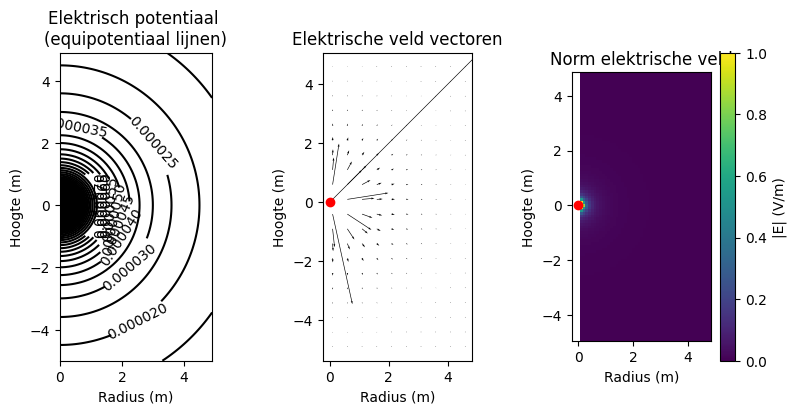

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\802447875.py:9: RuntimeWarning: divide by zero encountered in power
  return a * (x)**b
C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\802447875.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_functie, r, V[50], p0=(1e-4, -1), maxfev=4000)


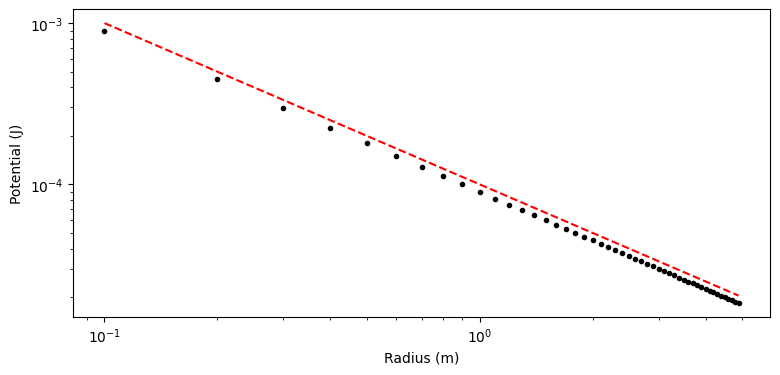

De exponent in de functie is -1.0


In [3]:
###
###Hier jouw code###
from scipy.optimize import curve_fit
#1

#2 log van het potentiaal tegen log van de straal
#3 fit van het potentiaal met de log van de straal
def exp_functie(x, a, b):
    return a * (x)**b

popt, pcov = curve_fit(exp_functie, r, V[50], p0=(1e-4, -1), maxfev=4000)

#a = np.polyfit(r, V[50], 49)
#p = np.poly1d(a)
r_fit = np.linspace(1e-1, r[-1], 1000)
V_fit = exp_functie(r_fit, *popt)

plt.figure(10,figsize=(9, 4))
plt.loglog(r, V[50], 'k.')
plt.loglog(r_fit, V_fit, 'r--')
plt.xlabel('Radius (m)')
plt.ylabel('Potential (J)')
plt.show()

#4 exponent
print('De exponent in de functie is', np.round(popt[1], 2))


###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

De exponent in de functie is -1.95


C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\2601860955.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


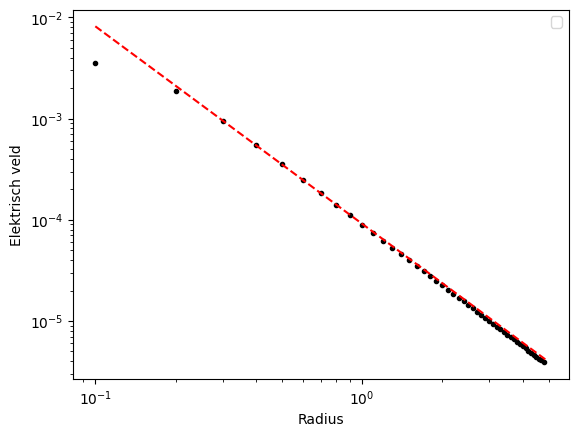

In [4]:
###
new_normE = normE[50]
poptE, pcovE = curve_fit(exp_functie, r_for_E[2:], new_normE[2:], p0=(1e-4, -2))


E_fit = exp_functie(r_fit, *poptE)

plt.figure()
plt.xlabel('Radius')
plt.ylabel('Elektrisch veld')
plt.loglog(r_for_E, normE[50], 'k.')
plt.loglog(r_fit, E_fit, 'r--')
plt.legend()

print('De exponent in de functie is', np.round(poptE[1], 2))


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 4  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

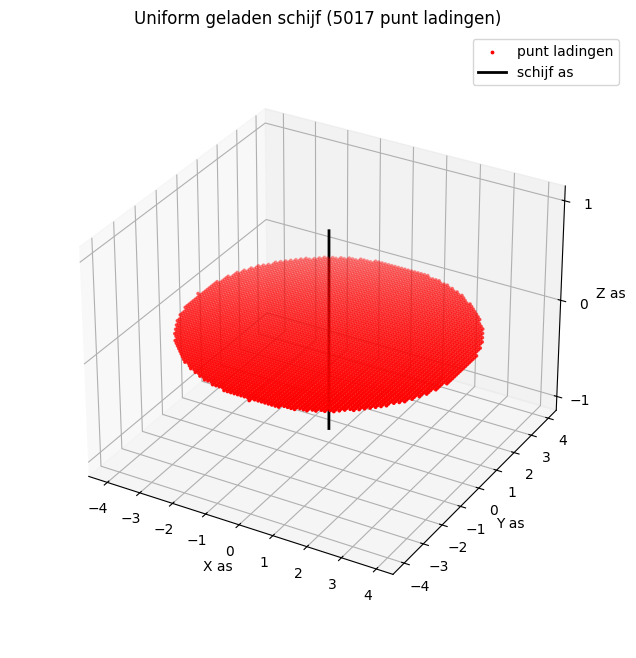

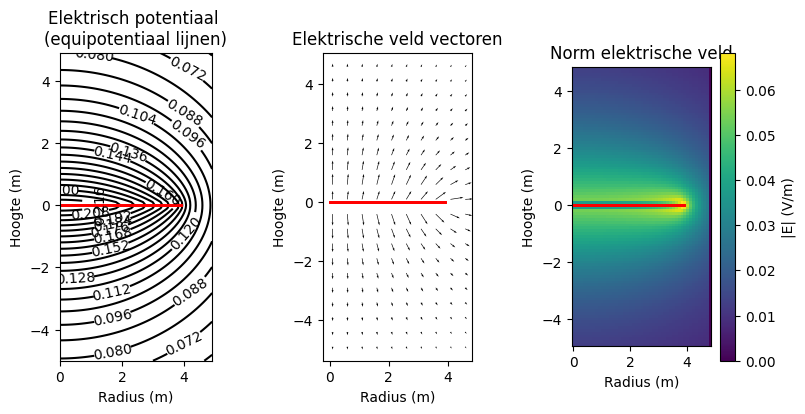

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. de diskradius variabele geeft de straal van de schijf. bij 0 zijn er geen puntladingen
2. gridstep bepaalt de afstand tussen twee puntenladingen
3. z coord DISK bepaalt de hoogte van de schijf in de z richting.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
# sigma = Q/A, ladingsdichtheid =lading / oppervlakte
lading_punt = charge_one_point
aantal_punten=number_point_charges_on_disk
R= disk_radius
Q = lading_punt*aantal_punten
A= np.pi * R**2
sigma = Q/A
print(sigma)

9.981004368650486e-13


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, 'potentiaal V[V]')

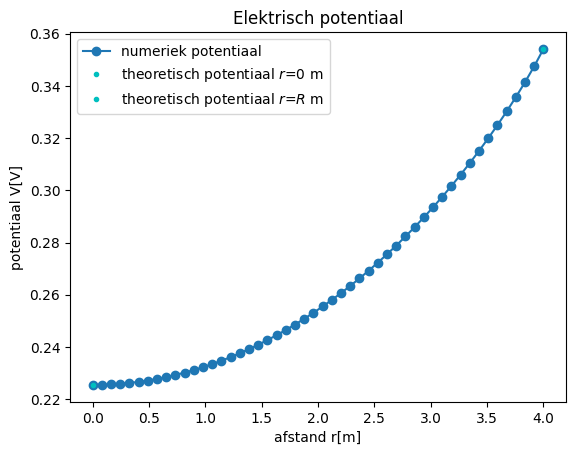

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
# idx_z_zero = 
r = np.linspace(0, R, 50)
V_r = (sigma / (2 * epsilon0)) * (np.sqrt(R**2 - r**2) + r * np.arcsin(r/R))

R = disk_radius
V_0 = (sigma * R) / (2 * epsilon0)      # centrum
V_R = (sigma * R * np.pi) / (4 * epsilon0)   # rand



r_R = disk_radius # straal van de schijf

plt.title(f"Elektrisch potentiaal")
plt.plot(r, V_r, "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("afstand r[m]")
plt.ylabel("potentiaal V[V]")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1057136721.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(z, V_z_t, 'r--', label="Griffiths Benadering ($R \gg z$)")


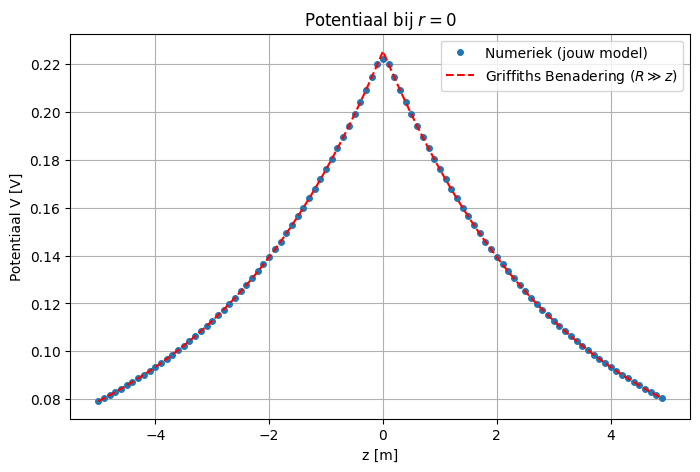

In [9]:

idx_r0 = np.argmin(np.abs(r))  # zoekt kleinste waarde voor r (dichtsbij 0)

V_z_n = V[:, idx_r0] # alle waardes van V waarvoor r=0, numeriek
V_z_t= (sigma/(2*epsilon0))*(np.sqrt(R**2+z**2)-np.abs(z)) # thoeretisch

# Plotten
plt.figure(figsize=(8, 5))
plt.plot(z, V_z_n, 'o', markersize=4, label="Numeriek (jouw model)")
plt.plot(z, V_z_t, 'r--', label="Griffiths Benadering ($R \gg z$)")

plt.xlabel("z [m]")
plt.ylabel("Potentiaal V [V]")
plt.title("Potentiaal bij $r = 0$")
plt.legend()
plt.grid(True)
plt.savefig("potentiaal_plot.pdf")
plt.show()



#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

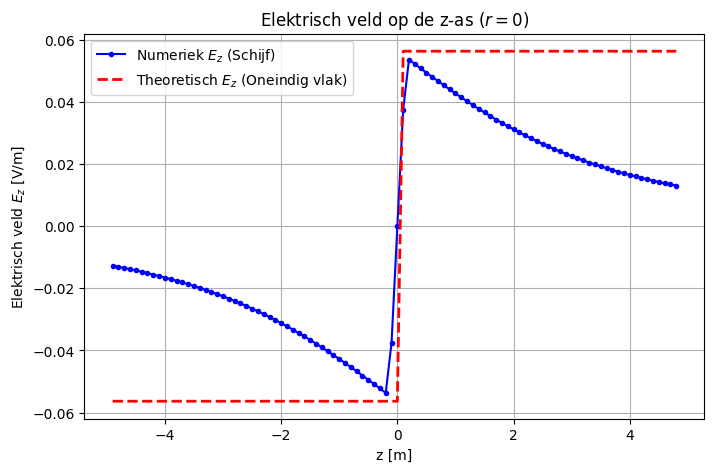

In [10]:

# 1. Vind de index waar r het dichtst bij 0 ligt in het E-grid
idx_r0_E = np.argmin(np.abs(r_for_E))

# 2. Pak de z-component (Ez) in plaats van de norm (normE)
# Ez laat de richting zien (positief boven de schijf, negatief eronder)
E_z_n = Ez[:, idx_r0_E] 

# 3. Bereken het theoretische veld voor een ONEINDIG oppervlak
# Formule: E = sigma / (2 * epsilon0)
# We gebruiken np.sign om de sprong bij z=0 te laten zien
E_z_t = (sigma / (2 * epsilon0)) * np.sign(z_for_E)

# Plotten
plt.figure(figsize=(8, 5))
plt.plot(z_for_E, E_z_n, 'bo-', markersize=3, label="Numeriek $E_z$ (Schijf)")
plt.plot(z_for_E, E_z_t, 'r--', linewidth=2, label="Theoretisch $E_z$ (Oneindig vlak)")


plt.xlabel("z [m]")
plt.ylabel("Elektrisch veld $E_z$ [V/m]")
plt.title("Elektrisch veld op de z-as ($r=0$)")
plt.legend()
plt.grid(True)
plt.savefig("elektrisch_veld_plot.pdf")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. rond r=0m, dus bij een kleine z, in de buurt van het centrum.
2. een verschil is dat bij het theoretische deel neemt het elektrische veld met de afstand niet af maar de blauwe lijn gaat met de afstand wel steeds meer naar nul. dit komt omdat bij een oneindige plaat het veld niet veranderd maar bij een schijf veranderd het wel. een ander verschil is dat de pieken van de rode (theoretische) lijn iets hoger komen te liggen dan de blauwe


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

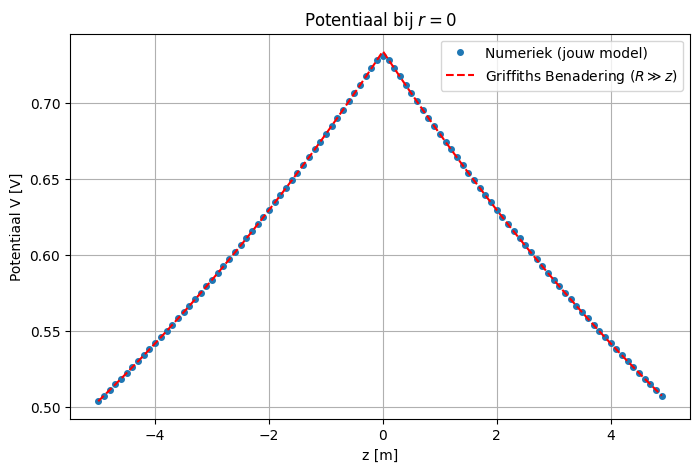
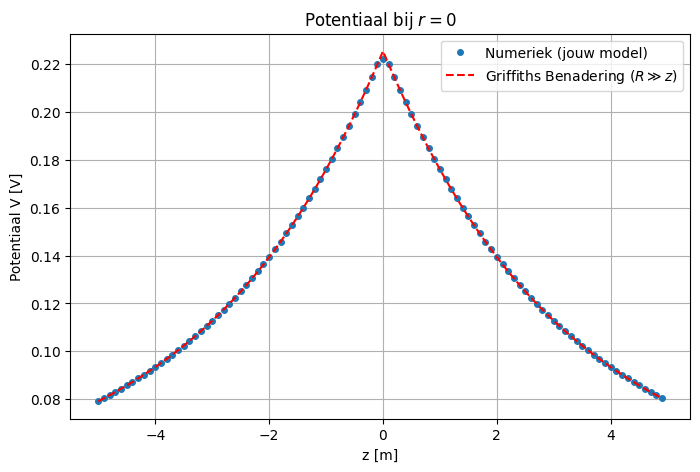

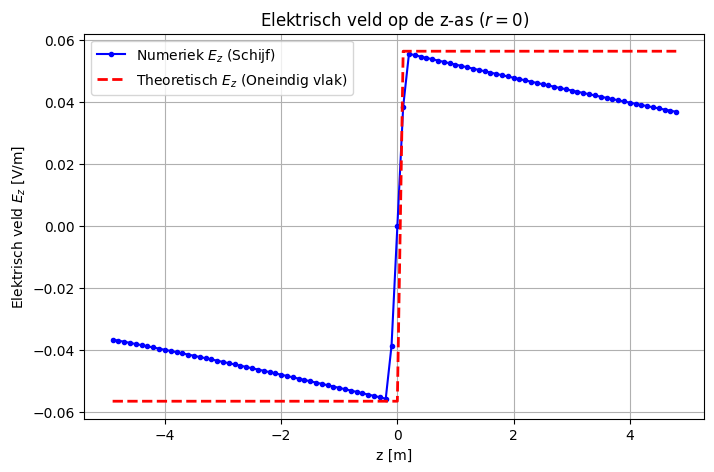
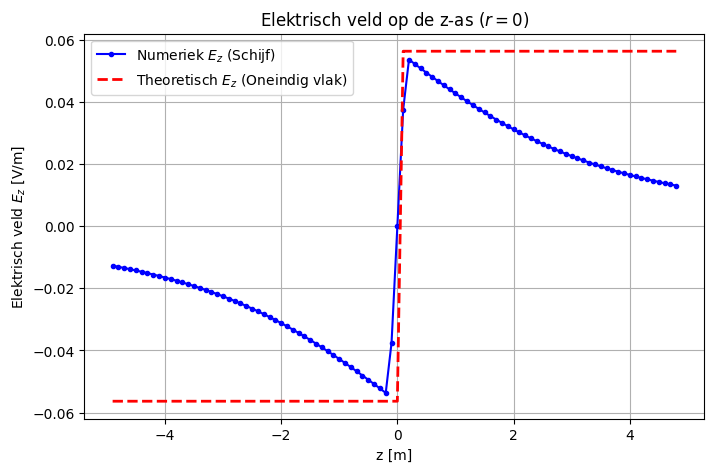

##### Antwoorden 2g
de bovenste plaatjes zijn telkens de grafieken met een grotere straal. het verschil bij het potenitaal is dat het bij een grotere straal te verhouding tussen de afstand en potentiaal afname bijna lineair is.en de potentiaal is ook veel groter dan bij een kleinere straal.
bij het elektrische veld is het verschil dat de pieken van het numerieke en theoretische bij een grotere straal bijna overeenkomen en dat het elektrische veld veel minder sterk afneemt.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Volgens de opdracht moet gelden:
$$E_{\text{schijf}} = 0.10 \cdot E_{\text{oneindig}}$$

$$\frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] = 0.10 \cdot \frac{\sigma}{2\epsilon_0}$$

De term $\frac{\sigma}{2\epsilon_0}$ valt aan beide kanten weg:
$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.10$$

$$\frac{z}{\sqrt{R^2 + z^2}} = 0.90$$

$$\frac{z^2}{R^2 + z^2} = 0.81$$

$$z^2 = 0.81(R^2 + z^2)$$
$$z^2 = 0.81R^2 + 0.81z^2$$
$$0.19z^2 = 0.81R^2$$


$$z^2 = \frac{0.81}{0.19}R^2 \approx 4.26R^2$$
$$z = \sqrt{4.26} \cdot R \approx 2.06 \cdot R$$

Voor een schijf met straal $R = 4$ meter is de benodigde hoogte:
$$z \approx 2.06 \cdot 4 = 8.24 \text{ meter}$$

Op een hoogte van **8.24 meter** boven het midden van de schijf is de elektrische veldsterkte nog maar 10% van de waarde die een oneindig geladen plaat zou hebben.

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

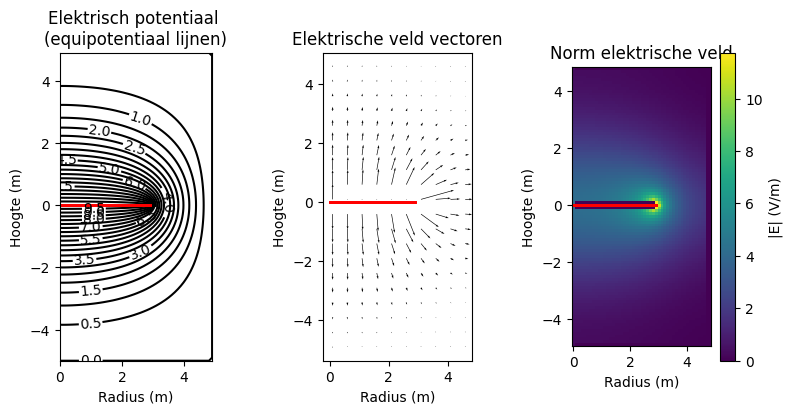

In [11]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)
disk_radius = 3

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step , idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

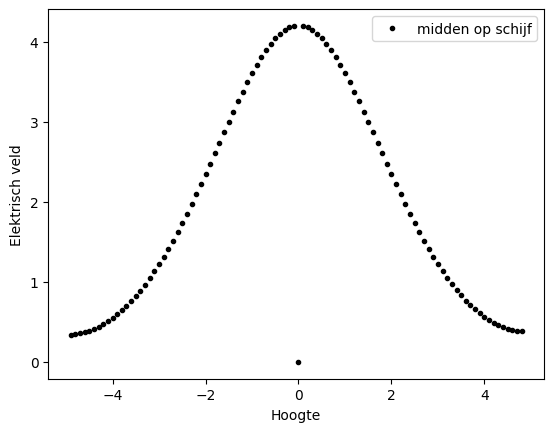

De norm van het elektrische veld zo dicht mogelijk op het midden is 4.201845192612321


In [12]:
# plt.figure()
# plt.plot(r[1:], Er[50])
# #print('De norm van het elektrisch veld op de as heel dicht bij het midden van de schijf', np.sqrt(Er[50]))

# index = np.where(r == np.round(disk_radius / 2))
# E_veld = normE[50]
# print(E_veld[index])

# normE_midden = 20

# print(Ez[15])
# plt.figure()
# plt.xlabel('Hoogte')
# plt.ylabel('Elektrisch veld')
# plt.plot(z[51:100], Ez[15], label = 'Elektrische veldsterkte op as van schijf')
# plt.legend()
# plt.show()

# normE_midden = normE[30]
# plt.plot(normE_midden)
# print(normE_midden)

# index_r0 = np.argmin(np.abs(r_for_E))
# normE_midden = normE[index_r0]

# plt.figure()
# plt.xlabel('Radius')
# plt.ylabel('norm van Eveld')
# plt.plot(r[1:], normE_midden, label='Midden van de schijf')
# plt.legend()
# plt.show()

plt.figure()
plt.xlabel('Hoogte')
plt.ylabel('Elektrisch veld')
plt.plot(z_for_E, normE[:,0], 'k.', label = 'midden op schijf')
plt.legend()
plt.show()

normE_midden = np.max(normE[:,0])
print('De norm van het elektrische veld zo dicht mogelijk op het midden is', normE_midden)


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?

2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b


Met de divergentiestelling:

$\nabla \cdot \vec E = \frac{\rho}{\epsilon _0}$

Waarbij $\rho$ de ladingsverdeling is in C/m, $\epsilon _0$ de permittiviteit van vacuum van $8.85418782 × 10-12 m^{-3} kg^{-1} s^4 A^2$, en E het elektrisch veld.



In [13]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.


# def fit(r, E0, a):
#     return E0 - a*r**2

# popt, pcov = curve_fit(fit, r[1:4], normE_midden[:3])
# # print(popt)

# # print('De oppervlakte lading in het midden van de schijf is', oppladingmidden, 'C/m^2')

# eveld = (np.max(normE_midden))


oppladingmidden = normE_midden * epsilon0
print('De oppervlaktelading op het midden van de schijf is', oppladingmidden, 'C/m^2')

# plt.figure()
# plt.xlabel('Radius')
# plt.ylabel('Norm elektrisch veld')
# plt.plot(r[1:], normE_midden)
# plt.plot(r[1:], fit(r[1:], *popt))
# plt.legend()
# plt.show()

De oppervlaktelading op het midden van de schijf is 3.720313733538949e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


De oppervlaktelading voor een uniform geladen schijf is 7.440627467077898e-11 C/m^2


C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1584674558.py:3: RuntimeWarning: invalid value encountered in sqrt
  opplading = Q / (2*np.pi*disk_radius * np.sqrt(disk_radius**2-r**2))
C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1584674558.py:3: RuntimeWarning: divide by zero encountered in divide
  opplading = Q / (2*np.pi*disk_radius * np.sqrt(disk_radius**2-r**2))


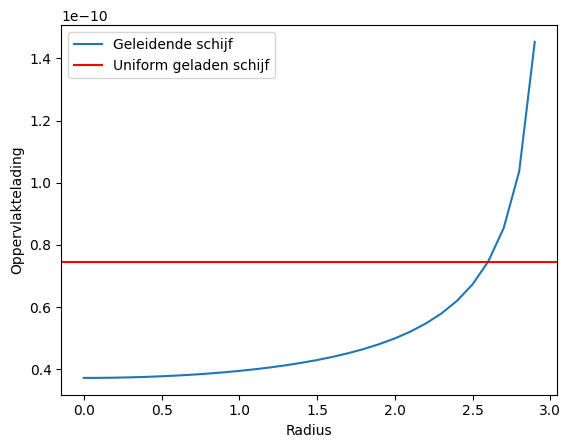

In [14]:
Q = oppladingmidden * 2 * np.pi * disk_radius**2 

opplading = Q / (2*np.pi*disk_radius * np.sqrt(disk_radius**2-r**2))


opplading_uniform = Q / (np.pi * disk_radius**2)
print('De oppervlaktelading voor een uniform geladen schijf is', opplading_uniform, 'C/m^2')

plt.figure()
plt.plot(r[:30], opplading[:30], label='Geleidende schijf')
plt.axhline(opplading_uniform, c='r', label = 'Uniform geladen schijf') 
plt.xlabel('Radius')
plt.ylabel('Oppervlaktelading')
plt.legend()
plt.show()


#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [15]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.

maximum = np.max(normE)
index = np.argmax(normE)
# print(index)
# print(len(normE))
# print(2479/98)
print('Het maximum elektrisch veld voor de schijf is', maximum)
print('Het maximum bevindt zich op', r_for_E[np.argmax(maximum)], 'm') # dit klopt niet
print('Het maximum is', maximum / normE_midden, 'keer hoger dan op het midden')

# print(np.argmax(normE))
# wat gebeurt er



Het maximum elektrisch veld voor de schijf is 11.752993215742134
Het maximum bevindt zich op 0.1 m
Het maximum is 2.7971028624296372 keer hoger dan op het midden


##### Antwoord 3d.5

Op de rand van de schijf is de straal van de schijf gelijk aan de positie r, waardoor in de vergelijking de onderkant van de breuk naar nul gaat. In een theoretische simulatie zal dus het elektrisch veld op de rand oneindig groot worden, en in het echt zal het ook een veel hoger elektrisch veld hebben dan de rest van de schijf. 


### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

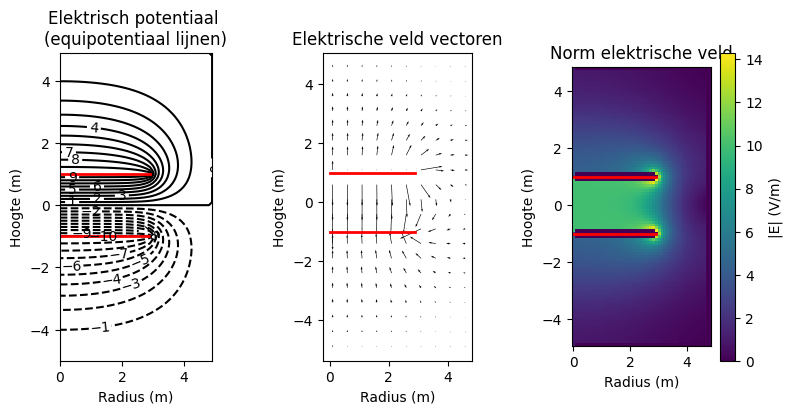

In [16]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


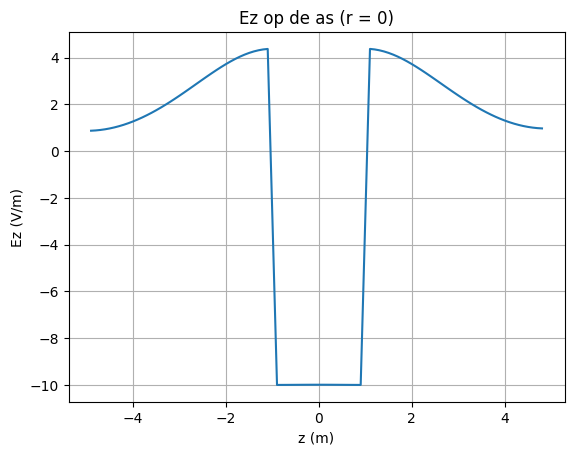

In [17]:
# Vind index waar r = 0
idx_r0 = np.argmin(np.abs(r_for_E - 0))

# Neem alle z, maar vaste r
Ez_axis = Ez[:, idx_r0]

plt.figure()
plt.plot(z_for_E, Ez_axis)
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("Ez op de as (r = 0)")
plt.grid()
plt.show()

# tussen platen is veld lineair, buiten neemt het af


#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
 1) Theoretisch elektrisch veld

twee geleidende platen op:
z = +d/2   met   V = +V₁  
z = -d/2   met   V = -V₁  
drie regio’s:
Regio I:     z > +d/2  
Regio II:   -d/2 < z < +d/2  
Regio III:   z < -d/2  
 Afleiding in Regio II (tussen de platen)

In ladingsvrije ruimte geldt de Laplace-vergelijking:
∇²V = 0
Door symmetrie hangt V alleen af van z:
d²V/dz² = 0
Integreren:
V(z) = Az + B
Randvoorwaarden:
V(+d/2) = +V₁  
V(-d/2) = -V₁  
Oplossen geeft:
A = 2V₁/d  
B = 0  
V(z) = (2V₁/d) z
E_z = - dV/dz
E_z = - 2V₁/d   (constant)
Regio I:     E = 0  
Regio II:    E = -2V₁/d (constant)  
Regio III:   E = 0  

2) Numeriek berekende elektrische veld op de as
numeriek is eindige schijven.
- In midden (r = 0, z = 0):  veld ong constant. (komt het veld goed overeen met
  E = -2V₁/d.)
- Dicht bij schijven:  veld sterker (piek).
- Buiten schijven: veld daalt naar nul.
De numerieke oplossing benadert de ideale theorie
goed in het midden, maar daarbuiten niet want theorie is niet hetzelfde als gemeten wnat bij gemeten is plaat eindig en bij theorie oneindig

3) Vergelijking met één enkele geleidende schijf
Eén schijf op potentiaal V₁:
- Het veld verspreidt zich in alle richtingen.
- Het veld in het midden is relatief zwak.
- Het veld is niet uniform.
Twee schijven (±V₁):
- Het veld tussen de schijven is sterker: E ≈ -2V₁/d
- Het veld is veel uniformer.
- Het veld is geconcentreerd tussen de platen.
Voordeel van twee schijven:
1) Sterker veld bij dezelfde spanning.
2) Uniform veld in het midden.
3) Controleerbaar via de afstand d.
Daarom wordt in de praktijk een
parallelplaatconfiguratie gebruikt
(bijvoorbeeld in een condensator),
en niet één enkele geleidende schijf.


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [18]:


# Gegeven parameters 
V1 = 10                # Volt
d = spacing_between_disks  # afstand tussen platen (m)
R = disk_radius        # straal van de schijf (m)

sigma = 2 * epsilon0 * V1 / d   # C/m^2 ladingsdichtheid

A = np.pi * R**2                # oppervlak van schijf
Q = sigma * A                   # lading per plaat (C)

C = epsilon0 * A / d            # F capaciteit


print("===== Resultaten twee geleidende schijven =====")
print(f"Afstand tussen schijven (d): {d:.3e} m")
print(f"Straal van schijf (R):       {R:.3e} m")
print()
print(f"Oppervlakteladingsdichtheid (sigma): {sigma:.3e} C/m^2")
print(f"Totale lading per schijf (Q):        {Q:.3e} C")
print(f"Totale lading systeem:               0 C")
print(f"Capaciteit (C):                      {C:.3e} F")


===== Resultaten twee geleidende schijven =====
Afstand tussen schijven (d): 2.000e+00 m
Straal van schijf (R):       3.000e+00 m

Oppervlakteladingsdichtheid (sigma): 8.854e-11 C/m^2
Totale lading per schijf (Q):        2.503e-09 C
Totale lading systeem:               0 C
Capaciteit (C):                      1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. opplading aan buitenkant van schijven is niet gelijk aan nul omdat de veldlijnen bij eindige schijven om de schijven krommen.
2. Net buiten het oppervlak van een geleider staat het elektrische veld loodrecht op het oppervlak en heeft een grootte van E = sigma/epsilon_0, terwijl binnen de geleider \(E = 0\); bij eindige schijven krommen de veldlijnen aan de randen waardoor daar een kleine oppervlaktelading en een versterkt veld kan zijn.


#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [19]:

idx_r0 = np.argmin(np.abs(r_for_E - 0))  # r = 0 (as)

idx_z_onder = np.argmin(np.abs(z_for_E - (z_pos_disk2 - grid_step)))  #  onder
idx_z_boven = np.argmin(np.abs(z_for_E - (z_pos_disk2 + grid_step)))  #  boven

Ez_onder = Ez[idx_z_onder, idx_r0]   #  onder onderste schijf
Ez_boven = Ez[idx_z_boven, idx_r0]   #  boven onderste schijf

sigma_onder = epsilon0 * Ez_onder
sigma_boven = epsilon0 * Ez_boven


print(f"Net onder de onderste schijf (z = {z_for_E[idx_z_onder]:.3f} m):")
print(f"    E_z = {Ez_onder:.3e} V/m")
print(f"    σ = {sigma_onder:.3e} C/m²")
print(f"Net boven de onderste schijf (z = {z_for_E[idx_z_boven]:.3f} m):")
print(f"    E_z = {Ez_boven:.3e} V/m")
print(f"    σ = {sigma_boven:.3e} C/m²")


Net onder de onderste schijf (z = -1.100 m):
    E_z = 4.377e+00 V/m
    σ = 3.875e-11 C/m²
Net boven de onderste schijf (z = -0.900 m):
    E_z = -1.000e+01 V/m
    σ = -8.858e-11 C/m²


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. werkelijke lading is niet uniform verdeeld, tussen platen grootste sigma, buiten platen wel kleine sigma want kormming veldlijnen, theorie zegt dat deze sigma nul is, dit komt niet overeen.
2. capaciteit is iets lager dan theorie doordat randeffechten het veld iets kleiner maken
3. veld tussen platen wordt groter, sigma gorter, capacitiet neemt toe waardoor veld tussen platen sterker en uniformer.


### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [20]:
def vlakkeplaat(A, d, k):
    C = (A * epsilon0 * k) / d # met A de oppervlakte van de plaat en k de relatieve permittiviteit
    return C

def cilinder(L, R1, R2, k): # met L de lengte van de cilinder condensator, R1 de straal van de binnenste cilinder en R2 de buitenste
    C = -(2*np.pi*epsilon0*L * k)/(np.log(R2 / R1))
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [21]:
print('De capaciteit van de eerste condensator is', np.round(vlakkeplaat(0.01, 0.001, 1.00058986) * 1e12, 2), 'picofarad')
print('De capaciteit van de tweede condensator is', np.round(cilinder(0.1, 0.009, 0.001, 1.00058986) * 1e12, 2), 'picofarad')
print('De capaciteit van de eerste condensator met verdubbelde afstand is', np.round(vlakkeplaat(0.01, 0.002, 1.00058986) * 1e12, 2), 'picofarad')
print('De capaciteit van de eerste gevuld met water op 20 graden is', np.round(vlakkeplaat(0.01, 0.001, 80.2) * 1e12, 2), 'picofarad')
print('De capaciteit van de tweede gevuld met water op 20 graden is', np.round(cilinder(0.1, 0.009, 0.001, 80.2) * 1e12, 2), 'picofarad')
print('De capaciteit van de eerste gevuld met PVC is', np.round(vlakkeplaat(0.01, 0.001, 3.18) * 1e12, 2), 'picofarad')
print('De capaciteit van de tweede gevuld met PVC is', np.round(cilinder(0.1, 0.009, 0.001, 3.18) * 1e12, 2), 'picofarad')


De capaciteit van de eerste condensator is 88.59 picofarad
De capaciteit van de tweede condensator is 2.53 picofarad
De capaciteit van de eerste condensator met verdubbelde afstand is 44.3 picofarad
De capaciteit van de eerste gevuld met water op 20 graden is 7100.91 picofarad
De capaciteit van de tweede gevuld met water op 20 graden is 203.06 picofarad
De capaciteit van de eerste gevuld met PVC is 281.56 picofarad
De capaciteit van de tweede gevuld met PVC is 8.05 picofarad


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [22]:
C_1 = 1e-12
k_lucht = 1.00058986
def lengtecilinder(r1, r2, C, k):
    return (np.log(r2 / r1) * C) / (2 * np.pi * epsilon0 * k)

lengte = (np.log(0.006 / 0.005) * C_1) / (2 * np.pi * epsilon0 * k_lucht)
print('De lengte van de cilinder condensator moet zijn', np.round(lengtecilinder(0.005, 0.006, C_1, k_lucht) * 1e3, 2), 'mm')

def oppvlakkeplaat(C, d, k):
    return (C * d) / (epsilon0 * k)

opp_2 = oppvlakkeplaat(C_1, 0.5e-3, k_lucht)
lengte2 = opp_2 / 0.006

print('De lengte van de vlakke plaat condensator moet zijn', np.round(lengte2 * 1e3, 2), 'mm')


De lengte van de cilinder condensator moet zijn 3.28 mm
De lengte van de vlakke plaat condensator moet zijn 9.41 mm


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. De antwoorden liggen in de juiste ordes van grootte voor een typische condensator, aangezien we een idealisatie van de vorm hebben genomen zal het echte antwoord een klein beetje verschillen maar de berekeningen zijn wel realistisch.
2. Door de afstand tussen de binnen en de buitenwand zo klein mogelijk te maken en vervolgens de formule aan te passen op basis van de echt gemeten data van de capaciteit.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [23]:
m = 1000 # kg
v = 70 / 3.6
tot_energie = 0.5 * m * v**2

print('De massa van het treintje is ongeveer', m, 'kg')
print('De totale energie van het treintje na afgeschoten worden is ongeveer', np.round(tot_energie * 1e-3, 2), 'kJ')

voltage = 10e3
C_treintje = (2 * tot_energie) / voltage**2
print('De totale capaciteit van de condensator is', np.round(C_treintje * 1e6, 2), 'microfarad')

print('De oppervlakte van een vlakke plaat condensator met deze capaciteit en plaatafstand 1 mm gevuld met water is', 
      np.round(oppvlakkeplaat(C_treintje, 0.001, 80.2), 2), 'm^2')



De massa van het treintje is ongeveer 1000 kg
De totale energie van het treintje na afgeschoten worden is ongeveer 189.04 kJ
De totale capaciteit van de condensator is 3780.86 microfarad
De oppervlakte van een vlakke plaat condensator met deze capaciteit en plaatafstand 1 mm gevuld met water is 5324.48 m^2


##### Antwoorden 5e

Zo een groot oppervlak is niet realistisch uitvoerbaar, maar het zou toch mogelijk moeten zijn door een ander medium te gebruiken met een grotere dielectrische constante waardoor de oppervlakte minder groot hoeft te zijn (want k is onderin de breuk).

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

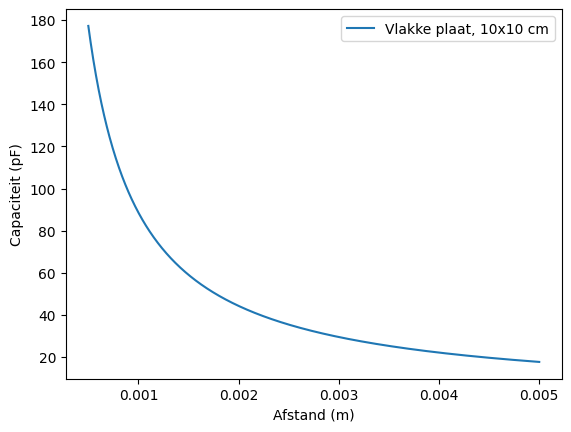

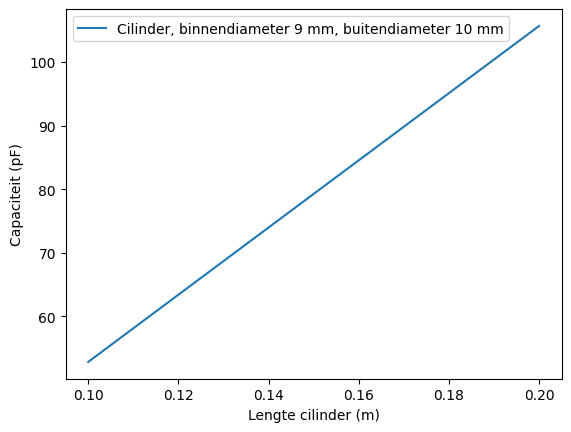

In [24]:
afstand_vlak = np.linspace(0.5e-3, 5e-3, 1000)
capaciteit_vlak = vlakkeplaat(0.01, afstand_vlak, k_lucht) * 1e12


plt.figure()
plt.xlabel('Afstand (m)')
plt.ylabel('Capaciteit (pF)')
plt.plot(afstand_vlak, capaciteit_vlak, label = 'Vlakke plaat, 10x10 cm')
plt.legend()
plt.show()

lengte_cilinder = np.linspace(0.1, 0.2, 1000)
capaciteit_cilinder = - cilinder(lengte_cilinder, 0.009, 0.01, k_lucht) * 1e12


plt.figure()
plt.xlabel('Lengte cilinder (m)')
plt.ylabel('Capaciteit (pF)')
plt.plot(lengte_cilinder, capaciteit_cilinder, label = 'Cilinder, binnendiameter 9 mm, buitendiameter 10 mm')
plt.legend()
plt.show()



## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [25]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [26]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

Wet van Gauss voor D veld:\
$\oint \vec D \cdot d\vec a = Q_{free, enc}$\
Waarbij $\vec D$ de elektrische displacement is en $Q_{free, enc}$ alle ingesloten vrije ladingen.\

Dit geeft: \
$DA = Q_{free, enc}$\
$Q_{free, enc} = \sigma A$\
dus $D = \sigma$

Het D veld in termen van het elektrisch veld is:\
$\vec D = \epsilon \vec E$\
dus
$\vec E = \frac{\sigma}{\epsilon} \hat n$  (wat ook volgt uit de wet van Gauss voor het E veld)

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

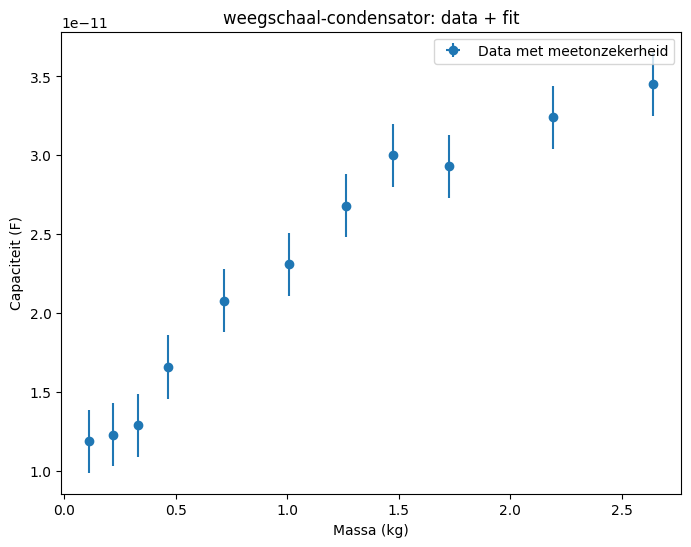

In [27]:
# Data ontwerpopdracht 2
capaciteitino = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8]) # pF
gewicht = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627]) # kg
echte_c = capaciteitino *1e-12 # F

# Onzekerheden
u_gewicht = 0.00005 # weegschaal nauwkeurig op 0.1 gram
u_cap = 2*1e-12     # waarde bleef niet op 1 waarde vandaar grote onzekerheid 
x_err = u_gewicht * np.ones_like(gewicht)  
y_err = u_cap * np.ones_like(gewicht) 

# Fitfunctie
def fitfunctie(x, a, b):
    return a / (b - x)

# Fitten
params, cov = curve_fit(fitfunctie, gewicht, echte_c, p0=(100,5))
a_fit, b_fit = params

# Voorspelling
x_fit = np.linspace(np.min(gewicht), np.max(gewicht), 500)
C_fit = fitfunctie(x_fit, a_fit, b_fit)

# Plotten
plt.figure(figsize=(8,6))
plt.errorbar(gewicht, echte_c, xerr=x_err, yerr=y_err, fmt='o', label='Data met meetonzekerheid')
# plt.plot(x_fit, C_fit, color='red', label='Fit: a/(b-x)')
# plt.plot(x,C*1e-12)
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.title("weegschaal-condensator: data + fit")
plt.legend()
plt.show()



[-2.55865284e-12  2.83544684e-11]


C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1958632214.py:4: RuntimeWarning: divide by zero encountered in divide
  return a/x + b
C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1958632214.py:15: RuntimeWarning: divide by zero encountered in divide
  sigma = epsilon0 * (1 + x1func) * (deltaV / d)
C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1958632214.py:18: RuntimeWarning: invalid value encountered in divide
  return D / (epsilon0 * (1 + x1))


Text(0, 0.5, 'E veld misschien in Coulomb')

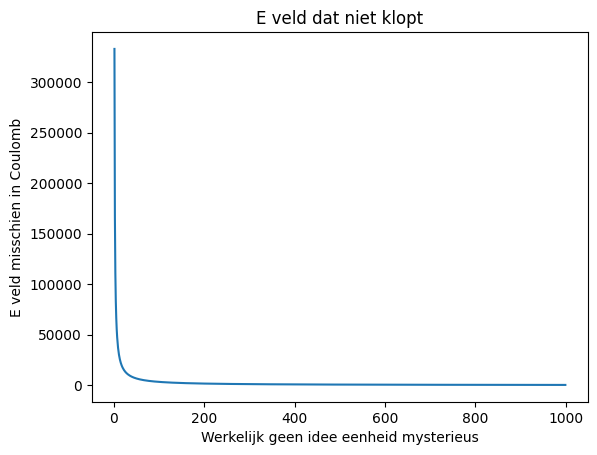

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt

def dielectrischefunctie(x, a, b):
    return a/x + b

val, cov = curve_fit(dielectrischefunctie, gewicht, echte_c)

print(val)


d = np.linspace(0, 0.03, 1000)
x1func = dielectrischefunctie(d, *val)
deltaV = 10 # random verzonnen bullshit vergeet niet aan te passen!

sigma = epsilon0 * (1 + x1func) * (deltaV / d)

def E_condensator(x1, D):
    return D / (epsilon0 * (1 + x1))

plt.figure()
plt.title('E veld dat niet klopt')
plt.plot(E_condensator(x1func, sigma))
plt.xlabel('Werkelijk geen idee eenheid mysterieus')
plt.ylabel('E veld misschien in Coulomb')

C:\Users\amegh\AppData\Local\Temp\ipykernel_9724\1958632214.py:18: RuntimeWarning: invalid value encountered in divide
  return D / (epsilon0 * (1 + x1))


Text(0.5, 1.0, 'Wat de hel')

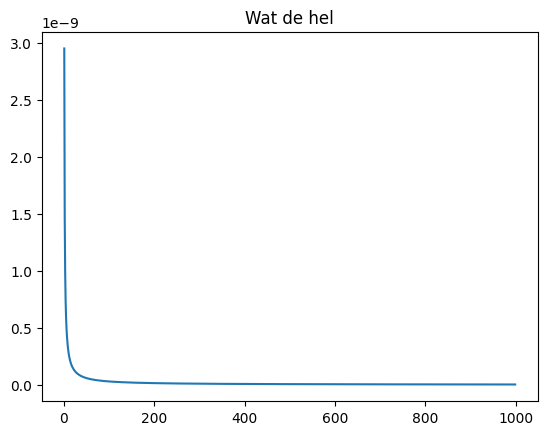

In [29]:
def capaciteit(A, E, deltaV):
    return (A * E * epsilon0)/ deltaV

plt.figure()
plt.plot(capaciteit(0.01, E_condensator(x1func, sigma), deltaV))
plt.title('Wat de hel')

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*